# Vector Data Cubes for Features Evolving in Space and Time

This is a Python translation of the [original computational notebook](https://github.com/loreabad6/vdc-space-time-feats/blob/main/notebook/vdc-showcase.md) to accompany the short paper manuscript **"Vector data cubes for features evolving in space and time"** submitted to AGILE 2024.

In this notebook, the expanded code on how to create vector data cubes (VDC) for shape-shifting features as described in section 3.2 (*Vector data cube implementation*) is included.


## Libraries

Install dependencies (run only once):

In [1]:
# Uncomment and run to install required packages
#pip install geopandas xvec xarray numpy pandas matplotlib shapely requests pyarrow pint-pandas

In [2]:
import zipfile
import tempfile
from pathlib import Path
import importlib
import sys
 
import numpy as np
import xvec
import pandas as pd
import geopandas as gpd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.cm import ScalarMappable
from shapely.ops import unary_union
from shapely.geometry import mapping
from datetime import datetime
import requests
from pint import UnitRegistry
from shapely.affinity import affine_transform
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

print("All libraries loaded successfully.")

All libraries loaded successfully.


Function to download from Zenodo

In [3]:
def download_zenodo(doi: str, filenames: list, out_dir: Path) -> list[Path]:
    """
    Download specific files from a Zenodo record.

    Parameters
    ----------
    doi : str
        Zenodo DOI, e.g. "10.5281/zenodo.7866738"
    filenames : list of str
        Names of files to download from the record.
    out_dir : Path
        Directory to save downloaded files.

    Returns
    -------
    list of Path
        Paths to the downloaded files.
    """
    record_id = doi.split(".")[-1]
    api_url = f"https://zenodo.org/api/records/{record_id}"
    resp = requests.get(api_url)
    resp.raise_for_status()
    files_meta = resp.json()["files"]

    out_dir.mkdir(parents=True, exist_ok=True)
    downloaded = []
    for f in files_meta:
        if f["key"] in filenames:
            dest = out_dir / f["key"]
            if not dest.exists():
                print(f"Downloading {f['key']} ...")
                r = requests.get(f["links"]["self"], stream=True)
                r.raise_for_status()
                with open(dest, "wb") as fh:
                    for chunk in r.iter_content(chunk_size=8192):
                        fh.write(chunk)
            downloaded.append(dest)
    return downloaded

## Data and Pre-processing

Both data sets are shared through Zenodo. We fetch the necessary data directly from the repository.

### Lava Flows in Fagradalsfjall, Iceland

The lava flow outlines for the Fagradalsfjall eruption are from [Pedersen et al. (2023)](https://doi.org/10.5281/zenodo.7866738).

#### Download and unzip

In [4]:
# set directory for temporary files
dir_tmp = Path(tempfile.mkdtemp())

lf_files = download_zenodo(
    doi="10.5281/zenodo.7866738",
    filenames=["outlines_pedersen_etal2022_v12.zip"],
    out_dir=dir_tmp,
)

lf_unzip_dir = dir_tmp / "unzipped_lf"
lf_unzip_dir.mkdir(exist_ok=True)
for zf in lf_files:
    with zipfile.ZipFile(zf, "r") as z:
        z.extractall(lf_unzip_dir)

# Find all GeoPackage outline files (recursive search)
fn_gpkg_lf = sorted(lf_unzip_dir.rglob("Outline*.gpkg"))

#### Read function

In [5]:
def read_lf(path: Path) -> gpd.GeoDataFrame:
    """
    Read a single lava-flow outline GeoPackage and extract the
    datetime from the filename.
    """
    gdf = gpd.read_file(path)
    fn = path.name
    parts = fn.split("_")
    # parts[1] = date (YYYYMMDD), parts[2] = time (HHMM)
    dt_str = parts[1] + parts[2].replace(".gpkg", "")
    dt = datetime.strptime(dt_str, "%Y%m%d%H%M")
    gdf["fn_gpkg"] = fn
    gdf["datetime"] = dt
    # One file has no CRS; set to EPSG:3057 (Iceland)
    if gdf.crs is None:
        gdf = gdf.set_crs(3057)
    else:
        gdf = gdf.to_crs(3057)
    return gdf

Combine all outlines into one GeoDataFrame

In [6]:
outlines_lf = pd.concat([read_lf(p) for p in fn_gpkg_lf], ignore_index=True)
outlines_lf = gpd.GeoDataFrame(outlines_lf, geometry="geometry")

#### Explore

We can look at the final object and have an initial idea of the contents

In [7]:
print(outlines_lf.info())

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 33 entries, 0 to 32
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   geometry  33 non-null     geometry      
 1   fn_gpkg   33 non-null     str           
 2   datetime  33 non-null     datetime64[us]
 3   id        0 non-null      float64       
 4   Area      7 non-null      float64       
 5   layer     4 non-null      str           
 6   path      4 non-null      str           
 7   STD_ID1   0 non-null      object        
 8   BLN_Flag  3 non-null      float64       
dtypes: datetime64[us](1), float64(3), geometry(1), object(1), str(3)
memory usage: 5.0+ KB
None


Quick plot of all polygon outlines coloured by datetime

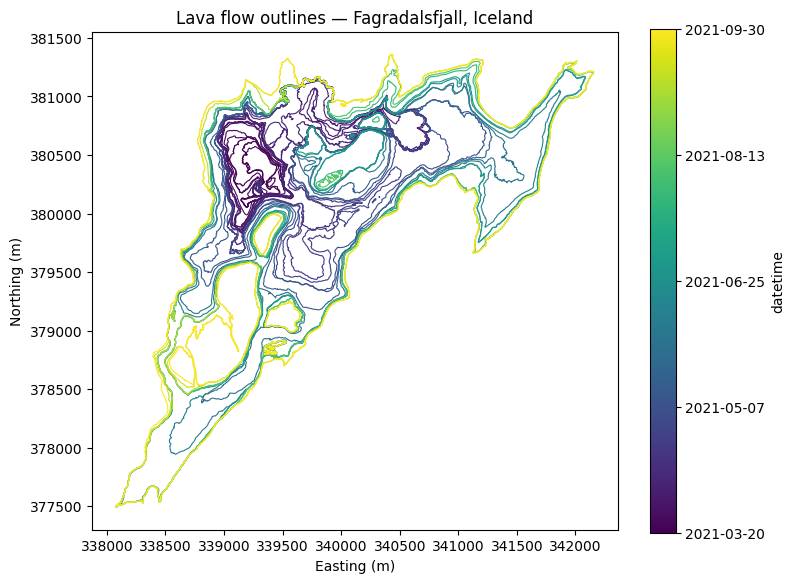

In [8]:
fig, ax = plt.subplots(figsize=(8, 6))
# Normalise datetime to a float for colour mapping
datetimes = outlines_lf["datetime"]
dt_numeric = (datetimes - datetimes.min()).dt.total_seconds()
norm = mcolors.Normalize(vmin=dt_numeric.min(), vmax=dt_numeric.max())
cmap_lf = plt.cm.viridis
for _, row in outlines_lf.iterrows():
    color = cmap_lf(norm(dt_numeric[row.name]))
    gpd.GeoDataFrame([row], geometry="geometry", crs=outlines_lf.crs).boundary.plot(
        ax=ax, color=color, linewidth=0.8
    )
# Colorbar
sm = ScalarMappable(cmap=cmap_lf, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
tick_vals = np.linspace(dt_numeric.min(), dt_numeric.max(), 5)
tick_labels = [
    (datetimes.min() + pd.Timedelta(seconds=v)).strftime("%Y-%m-%d")
    for v in tick_vals
]
cbar.set_ticks(tick_vals)
cbar.set_ticklabels(tick_labels)
cbar.set_label("datetime")
ax.set_title("Lava flow outlines — Fagradalsfjall, Iceland")
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
plt.tight_layout()
plt.savefig('../data/output/Lava flow outlines.png', bbox_inches='tight', pad_inches=0)
plt.show()
plt.close()

#### Prepare for VDC

The final step is to make sure we have a single geometry per timestamp. For this, we group by datetime and summarise the geometries for each data with a union. We add a step to make the geometry valid in case the union operation caused any topological issues.

In [9]:
outlines_lf = (
    outlines_lf
    .groupby("datetime", as_index=False)["geometry"]
    .apply(lambda g: unary_union(g))           # union per date  (≈ st_combine)
    .rename(columns={"geometry": "geometry"})
)
outlines_lf = gpd.GeoDataFrame(outlines_lf, geometry="geometry", crs=3057)
outlines_lf["geometry"] = outlines_lf["geometry"].make_valid()

c:\Users\b1120440\OneDrive - Universität Salzburg\MorphEO\morpheo\.venv\Lib\site-packages\shapely\constructive.py:752: RuntimeWarning: invalid value encountered in make_valid
  return lib.make_valid(geometry, **kwargs)


Now our data is ready to be coerced to a VDC.

### Landslide in Butangbunasi, Taiwan

The Butangbunasi landslide outlines can be obtained from Hölbling et al. (2024)

#### Download and unzip

In [10]:
ls_files = download_zenodo(
    doi="10.5281/zenodo.10635102",
    filenames=["outlines.zip", "Butangbunasi_OBIA_statistics.csv"],
    out_dir=dir_tmp,
)

ls_unzip_dir = dir_tmp / "unzipped_ls"
ls_unzip_dir.mkdir(exist_ok=True)
for zf in ls_files:
    if zf.suffix == ".zip":
        with zipfile.ZipFile(zf, "r") as z:
            z.extractall(ls_unzip_dir)

# Find GeoPackage files
mapping_ls = sorted((ls_unzip_dir / "outlines").rglob("*.gpkg"))

Read and combine outlines

In [11]:
# Read CSV with extra statistics
stats_path = next(f for f in ls_files if f.suffix == ".csv")
stats = pd.read_csv(stats_path)

# Read function
def read_ls(path: Path) -> gpd.GeoDataFrame:
    gdf = gpd.read_file(path)
    gdf["fn_gpkg"] = path.name
    return gdf

# Cmbine outlines and join with CSV 
outlines_ldsl = pd.concat([read_ls(p) for p in mapping_ls], ignore_index=True)
outlines_ldsl = gpd.GeoDataFrame(outlines_ldsl, geometry="geometry")
outlines_ldsl = outlines_ldsl.merge(stats, left_on="fn_gpkg", right_on="file", how="left")

#### Explore

We can look at the final object and have an initial idea of the contents.

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 124 entries, 0 to 123
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   Area_ha            124 non-null    float64 
 1   Class              124 non-null    str     
 2   geometry           124 non-null    geometry
 3   fn_gpkg            124 non-null    str     
 4   satellite_sensor   124 non-null    str     
 5   date               124 non-null    str     
 6   landslide_area_ha  124 non-null    float64 
 7   lake_area_ha       47 non-null     float64 
 8   file               124 non-null    str     
dtypes: float64(3), geometry(1), str(5)
memory usage: 17.7 KB
None


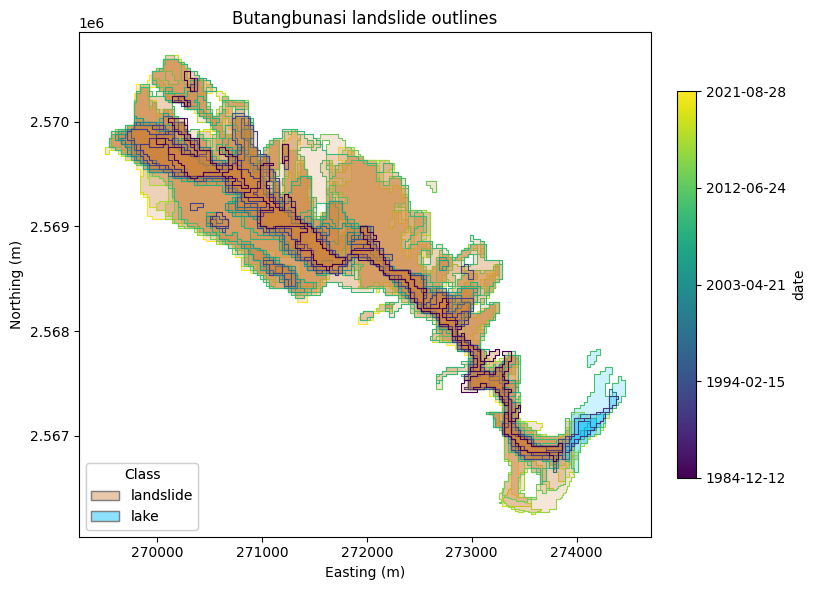

In [13]:
print(outlines_ldsl.info())

fig, ax = plt.subplots(figsize=(8, 6))

outlines_ldsl_plot = outlines_ldsl.sort_values("date", ascending=False).copy()

# Explicitly convert date column — handles both datetime.date and string inputs
outlines_ldsl_plot["date_dt"] = pd.to_datetime(
    outlines_ldsl_plot["date"].astype(str)
)

# Use float days since min date instead of raw nanoseconds — more stable
date_min = outlines_ldsl_plot["date_dt"].min()
date_max = outlines_ldsl_plot["date_dt"].max()
dates_num = (outlines_ldsl_plot["date_dt"] - date_min).dt.days.astype(float)
norm_date = mcolors.Normalize(vmin=dates_num.min(), vmax=dates_num.max())
cmap_date = plt.cm.viridis

fill_colors = {"landslide": "peru", "lake": "deepskyblue"}

for _, row in outlines_ldsl_plot.iterrows():
    if row["geometry"] is None:
        continue
    edge_color = cmap_date(norm_date(dates_num[row.name]))
    face_color = mcolors.to_rgba(fill_colors.get(row["Class"], "grey"), alpha=0.2)
    gpd.GeoSeries([row["geometry"]], crs=outlines_ldsl.crs).plot(
        ax=ax, facecolor=face_color, edgecolor=edge_color, linewidth=0.8,
    )

# Class legend
legend_fills = [
    Patch(facecolor=mcolors.to_rgba("peru", 0.4),        edgecolor="grey", label="landslide"),
    Patch(facecolor=mcolors.to_rgba("deepskyblue", 0.4), edgecolor="grey", label="lake"),
]
leg = ax.legend(handles=legend_fills, title="Class", loc="lower left")
ax.add_artist(leg)

# Colorbar — tick labels converted back from float days to real dates
sm = ScalarMappable(cmap=cmap_date, norm=norm_date)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, fraction=0.03, pad=0.04)
tick_vals = np.linspace(dates_num.min(), dates_num.max(), 5)
tick_labels = [
    (date_min + pd.Timedelta(days=int(v))).strftime("%Y-%m-%d")
    for v in tick_vals
]
cbar.set_ticks(tick_vals)
cbar.set_ticklabels(tick_labels)
cbar.set_label("date")

ax.set_title("Butangbunasi landslide outlines")
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
plt.tight_layout()
plt.savefig('../data/output/Butangbunasi landslide outlines.png', bbox_inches='tight', pad_inches=0)
plt.show()
plt.close()

We see here that the data does not only contain the landslide outlines but also the delineation of a dammed lake.

#### Prepare for VDC

In [14]:
ureg = UnitRegistry()

outlines_ldsl["date"] = pd.to_datetime(outlines_ldsl["date"]).dt.date

# Remove 2018-11-08 reference outline
outlines_ldsl = outlines_ldsl[
    outlines_ldsl["date"] != datetime(2018, 11, 8).date()
].copy()

# Group by date and Class, summarise geometry + attributes
def summarise_group(grp):
    return pd.Series({
        "geometry": unary_union(grp["geometry"]),
        "sensor": grp["satellite_sensor"].iloc[0],
        "area_ldsl_ha": grp["landslide_area_ha"].iloc[0],
        "area_lake_ha": grp["lake_area_ha"].iloc[0],
    })

outlines_ldsl = (
    outlines_ldsl
    .groupby(["date", "Class"], as_index=False)
    .apply(summarise_group)
    .reset_index(drop=True)
)
outlines_ldsl = gpd.GeoDataFrame(outlines_ldsl, geometry="geometry")

# Single 'area' column depending on Class
outlines_ldsl["area_ha"] = outlines_ldsl.apply(
    lambda r: r["area_ldsl_ha"] if r["Class"] == "landslide" else r["area_lake_ha"],
    axis=1,
)
outlines_ldsl = outlines_ldsl.drop(columns=["area_ldsl_ha", "area_lake_ha"])
outlines_ldsl = outlines_ldsl.rename(columns={"Class": "class"})

# Complete all date × class combinations (fills missing with NaN)
all_dates = outlines_ldsl["date"].unique()
all_classes = outlines_ldsl["class"].unique()
idx = pd.MultiIndex.from_product([all_dates, all_classes], names=["date", "class"])
outlines_ldsl = (
    outlines_ldsl
    .set_index(["date", "class"])
    .reindex(idx)
    .reset_index()
)
outlines_ldsl = gpd.GeoDataFrame(outlines_ldsl, geometry="geometry")

## VDC creation

### Array format

We will start creating an array VDC for the shape-evolving features. For this, we create an array object containing the data, i.e., the measure, that in this case are the changing geometries, and the dimensions of the array that correspond to the length of unique summary geometries (in this case 1), and of unique datetime strings.

Finally, we create a dimensions object that includes the summary geometry for our shape-evolving features. This can be the union of all the changing geometries or the centroid of those or the point from which the lava erupts or the landslide scar, or any other point the analyst sees adequate.

#### Lava flow VDC

For the lava flow, we do not use a unique identifier (id) because this is the only feature of this class under analysis. That means we are not including a second lava flow, e.g. the one in Grindavík, in the same cube, although we could when data is available.

In [15]:
# Lava flow array
datetimes_lf = outlines_lf["datetime"].tolist()
geoms_lf     = outlines_lf["geometry"].tolist()

# Summary geometry: centroid of the union of all geometries
geom_sum_lf = unary_union(geoms_lf)
centroid_lf = geom_sum_lf.centroid

# Build xarray DataArray with a GeometryIndex dimension (xvec)
#   dims: geom_sum (size 1), datetime
cube_arr_lf = xr.DataArray(
    data=np.array(geoms_lf, dtype=object).reshape(1, len(datetimes_lf)),
    dims=["geom_sum", "datetime"],
    coords={
        "geom_sum": [centroid_lf],
        "datetime": datetimes_lf,
    },
    name="geometry",
).assign_coords(
    geom_sum=xr.Variable("geom_sum", [centroid_lf])
)

# Attach GeometryIndex so xvec can work with it
cube_arr_lf = cube_arr_lf.xvec.set_geom_indexes("geom_sum", crs=3057)

print(cube_arr_lf)


<xarray.DataArray 'geometry' (geom_sum: 1, datetime: 30)> Size: 240B
array([[<POLYGON ((339233.657 380352.677, 339239.497 380358.037, 339244.075 380362.7...>,
        <POLYGON ((339159.284 380472.318, 339159.28 380472.349, 339159.117 380473.27...>,
        <POLYGON ((339346.729 380535.692, 339346.485 380535.113, 339343.839 380535.4...>,
        <POLYGON ((339207.874 380067.142, 339206.481 380070.973, 339205.667 380079.1...>,
        <POLYGON ((339066.822 380389.192, 339066.112 380390.503, 339062.624 380396.0...>,
        <POLYGON ((339503.976 380140.497, 339502.91 380141.212, 339494.995 380144.58...>,
        <POLYGON ((339567.449 380135.333, 339573.394 380142.217, 339578.057 380148.0...>,
        <POLYGON ((339506.728 380309.889, 339511.562 380312.506, 339515.247 380315.5...>,
        <POLYGON ((339030.9 380289.207, 339031.162 380289.613, 339032.035 380290.963...>,
        <POLYGON ((339360.733 380155.005, 339361.851 380155.117, 339367.436 380154.6...>,
        <MULTIPOLYGON (((338969

c:\Users\b1120440\OneDrive - Universität Salzburg\MorphEO\morpheo\.venv\Lib\site-packages\shapely\set_operations.py:553: RuntimeWarning: invalid value encountered in unary_union
  return lib.unary_union(collections, **kwargs)


In [16]:
# Illustrate: union as summary geometry instead of centroid
geom_union_lf = unary_union(geoms_lf)
cube_arr_lf_union = xr.DataArray(
    data=np.array(geoms_lf, dtype=object).reshape(1, len(datetimes_lf)),
    dims=["geom_sum", "datetime"],
    coords={"geom_sum": [geom_union_lf], "datetime": datetimes_lf},
    name="geometry",
).xvec.set_geom_indexes("geom_sum", crs=3057)
print(cube_arr_lf_union)
# We keep using the centroid version from here on.

<xarray.DataArray 'geometry' (geom_sum: 1, datetime: 30)> Size: 240B
array([[<POLYGON ((339233.657 380352.677, 339239.497 380358.037, 339244.075 380362.7...>,
        <POLYGON ((339159.284 380472.318, 339159.28 380472.349, 339159.117 380473.27...>,
        <POLYGON ((339346.729 380535.692, 339346.485 380535.113, 339343.839 380535.4...>,
        <POLYGON ((339207.874 380067.142, 339206.481 380070.973, 339205.667 380079.1...>,
        <POLYGON ((339066.822 380389.192, 339066.112 380390.503, 339062.624 380396.0...>,
        <POLYGON ((339503.976 380140.497, 339502.91 380141.212, 339494.995 380144.58...>,
        <POLYGON ((339567.449 380135.333, 339573.394 380142.217, 339578.057 380148.0...>,
        <POLYGON ((339506.728 380309.889, 339511.562 380312.506, 339515.247 380315.5...>,
        <POLYGON ((339030.9 380289.207, 339031.162 380289.613, 339032.035 380290.963...>,
        <POLYGON ((339360.733 380155.005, 339361.851 380155.117, 339367.436 380154.6...>,
        <MULTIPOLYGON (((338969

c:\Users\b1120440\OneDrive - Universität Salzburg\MorphEO\morpheo\.venv\Lib\site-packages\shapely\set_operations.py:553: RuntimeWarning: invalid value encountered in unary_union
  return lib.unary_union(collections, **kwargs)


#### Landslide VDC

For the landslide example we have added also the landslide-dammed lake outlines. The lake has been present in seven of the Landsat scenes mapped and therefore can serve as an example on how to handle absence in the data, as well as a second feature set in a VDC.

In this example, we add class as an extra dimension, which will mark whether the shape-evolving geometry is a landslide or a lake. For this particular case this dimension becomes redundant since there are two classes and two summary geometries, however, when we deal with more landslides and associated lakes, this could become useful.

We will perform some extra data wrangling to create this cube. Namely, we compute the summary geometry on the original array and perform again a complete case check to fill values with NAs for every combination of date, class and geom_sum.

Further, this dataset contains other information that can be mapped to the attributes such as the sensor and area. We will construct separate arrays for these and add them all to the cube.

In [17]:
# Landslide array
dates_ls    = sorted(outlines_ldsl["date"].unique())
classes_ls  = sorted(outlines_ldsl["class"].unique())
 
# Summary geometry per class: centroid of the union of all geometries
def class_centroid(cls):
    geoms = outlines_ldsl.loc[outlines_ldsl["class"] == cls, "geometry"].dropna()
    return unary_union(geoms).centroid
 
sum_geoms = {cls: class_centroid(cls) for cls in classes_ls}
 
# Sort outlines_ldsl for correct array stacking
outlines_ldsl_sorted = (
    outlines_ldsl
    .set_index(["class", "date"])
    .sort_index()
    .reset_index()
)
 
n_geom   = len(classes_ls)
n_class  = len(classes_ls)
n_date   = len(dates_ls)
 
# Arrays for each attribute  (shape: n_class × n_date)
def make_array(col):
    arr = np.empty((n_class, n_date), dtype=object)
    for i, cls in enumerate(classes_ls):
        for j, dt in enumerate(dates_ls):
            row = outlines_ldsl_sorted[
                (outlines_ldsl_sorted["class"] == cls) &
                (outlines_ldsl_sorted["date"]  == dt)
            ]
            arr[i, j] = row[col].iloc[0] if not row.empty else None
    return arr
 
geom_arr   = make_array("geometry")
area_arr   = make_array("area_ha")
sensor_arr = make_array("sensor")
 
# xvec requires geom_sum to be a proper dimension (not a non-dimension
# coordinate attached to another dim). We use geom_sum as the primary dim,
# with class as a scalar coordinate alongside it — one centroid per class.
geom_sum_list = [sum_geoms[c] for c in classes_ls]
 
ds_ldsl = xr.Dataset(
    {
        "geometry": xr.DataArray(geom_arr,   dims=["geom_sum", "date"]),
        "area_ha":  xr.DataArray(area_arr,   dims=["geom_sum", "date"]),
        "sensor":   xr.DataArray(sensor_arr, dims=["geom_sum", "date"]),
    },
    coords={
        "geom_sum": geom_sum_list,            # one centroid per class
        "class":    ("geom_sum", classes_ls), # class label alongside
        "date":     dates_ls,
    },
)
 
# Now geom_sum is a real dimension coordinate -> xvec can attach a GeometryIndex
cube_arr_ldsl = ds_ldsl.xvec.set_geom_indexes("geom_sum", crs=outlines_ldsl.crs)
print(cube_arr_ldsl)
 

<xarray.Dataset> Size: 1kB
Dimensions:   (geom_sum: 2, date: 20)
Coordinates:
  * geom_sum  (geom_sum) object 16B POINT (274148.347513089 2567227.57526178)...
    class     (geom_sum) <U9 72B 'lake' 'landslide'
  * date      (date) object 160B 1984-12-12 1989-10-23 ... 2016-12-04 2021-08-28
Data variables:
    geometry  (geom_sum, date) object 320B None ... MULTIPOLYGON (((272062.5 ...
    area_ha   (geom_sum, date) object 320B nan nan 5.312 ... 395.9 382.3 387.9
    sensor    (geom_sum, date) object 320B nan nan ... 'Landsat 8' 'Landsat 8'
Indexes:
    geom_sum  GeometryIndex (crs=None)


### Tabular format

In geopandas we represent the "spatial face" and "temporal face" of the cube as two separate GeoDataFrames linked by a key. This mirrors cubble's face_spatial() / face_temporal() pattern.

From the original notebook: 

"For this format, we need to define a key and index. The key is the identifier of the spatial face of the cube while the index is the identifier of the temporal face. We then use index = time and we should use key = geom_sum. This works when creating the cubble object but the algorithm to display the temporal face gets stuck as it tries to add a WKT geometry to every entry. There is one “hack” to handle this when coercing from a stars object. Internally, cubble adds an id column to the data, so we can call key = id and the cube creation in its spatial and temporal forms will work. This is the approach we use for the lava flow VDC. For the landslide VDC we added the column class as the key, which becomes then the identifier. Better ways to handle this will be suggested to cubble in future work."

#### Lava flow VDC


In [18]:
# Spatial face: one row per unique summary geometry  (≈ face_spatial)
spatial_lf = gpd.GeoDataFrame(
    {"id": [1], "geom_sum": [centroid_lf]},
    geometry="geom_sum",
    crs=3057,
)

# Temporal face: one row per (id, datetime)  (≈ face_temporal)
temporal_lf = outlines_lf.copy()
temporal_lf["id"] = 1
# keep the changing geometry column name
temporal_lf = temporal_lf.rename(columns={"geometry": "geometry"})

print("=== Spatial face (lava flow) ===")
print(spatial_lf)
print("\n=== Temporal face (lava flow) ===")
print(temporal_lf)

# Check time-series gaps  (≈ tsibble)
dts = pd.Series(sorted(temporal_lf["datetime"].unique()))
gaps = dts.diff().dropna()
print("\nTime intervals in lava flow series:")
print(gaps.value_counts())

=== Spatial face (lava flow) ===
   id                      geom_sum
0   1  POINT (339859.695 380008.49)

=== Temporal face (lava flow) ===
              datetime                                           geometry  id
0  2021-03-20 07:45:00  POLYGON ((339233.657 380352.677, 339239.497 38...   1
1  2021-03-20 12:40:00  POLYGON ((339159.284 380472.318, 339159.28 380...   1
2  2021-03-21 11:30:00  POLYGON ((339346.729 380535.692, 339346.485 38...   1
3  2021-03-22 13:22:00  POLYGON ((339207.874 380067.142, 339206.481 38...   1
4  2021-03-23 10:05:00  POLYGON ((339066.822 380389.192, 339066.112 38...   1
5  2021-03-26 12:52:00  POLYGON ((339503.976 380140.497, 339502.91 380...   1
6  2021-03-29 13:19:00  POLYGON ((339567.449 380135.333, 339573.394 38...   1
7  2021-03-30 13:11:00  POLYGON ((339506.728 380309.889, 339511.562 38...   1
8  2021-03-31 12:10:00  POLYGON ((339030.9 380289.207, 339031.162 3802...   1
9  2021-04-05 10:10:00  POLYGON ((339360.733 380155.005, 339361.851 38...   1
10

#### Landslide VDC

In [19]:
# Add geom_sum per class to outlines_ldsl_m
outlines_ldsl_m = outlines_ldsl.copy()
outlines_ldsl_m["geom_sum"] = outlines_ldsl_m["class"].map(sum_geoms)

# Spatial face
spatial_ldsl = gpd.GeoDataFrame(
    {
        "class":    classes_ls,
        "geom_sum": [sum_geoms[c] for c in classes_ls],
    },
    geometry="geom_sum",
    crs=outlines_ldsl.crs,
)

# Temporal face
temporal_ldsl = outlines_ldsl_m[["date", "class", "geometry", "sensor", "area_ha", "geom_sum"]].copy()
temporal_ldsl = gpd.GeoDataFrame(temporal_ldsl, geometry="geometry")

print("=== Spatial face (landslide) ===")
print(spatial_ldsl)
print("\n=== Temporal face (landslide) ===")
print(temporal_ldsl)

# Without NA rows
print("\n=== Temporal face (landslide, no NAs) ===")
print(temporal_ldsl.dropna(subset=["geometry"]))

=== Spatial face (landslide) ===
       class                        geom_sum
0       lake  POINT (274148.348 2567227.575)
1  landslide  POINT (271664.918 2568861.929)

=== Temporal face (landslide) ===
          date      class                                           geometry  \
0   1984-12-12  landslide  MULTIPOLYGON (((271637.5 2568620, 271637.5 256...   
1   1984-12-12       lake                                               None   
2   1989-10-23  landslide  MULTIPOLYGON (((273712.5 2566845, 273562.5 256...   
3   1989-10-23       lake                                               None   
4   1990-10-10  landslide  MULTIPOLYGON (((273737.5 2566845, 273737.5 256...   
5   1990-10-10       lake  MULTIPOLYGON (((273887.5 2566870, 273887.5 256...   
6   1992-10-31  landslide  MULTIPOLYGON (((273462.5 2566820, 273462.5 256...   
7   1992-10-31       lake  POLYGON ((273950 2566870, 273925 2566870, 2739...   
8   1994-09-03  landslide  MULTIPOLYGON (((273500 2566820, 273462.5 25668... 

## Showcase

In this section, we will demonstrate some of the operations that are supported now for VDCs, and some of the operations that we would like to implement in future work.

We will use the created cubes (lava flow, landslide) interchangeably, considering that most of the operations (given the data structure, e.g., extra dimensions, extra attributes) can be applied to both examples.

### Cube operations

#### Geometric measurements


In [20]:
# Array VDC
cube_arr_lf_area = cube_arr_lf.copy()
areas_lf = np.vectorize(lambda g: g.area if g is not None else np.nan)(
    cube_arr_lf.values
)
print("Areas (array VDC, lava flow):", areas_lf)

# Tabular VDC
temporal_lf["area"] = temporal_lf["geometry"].area
print(temporal_lf[["datetime", "area"]])

Areas (array VDC, lava flow): [[  54516.91911556   74062.8515166   136666.48595888  170888.01434856
   187948.12784603  240264.15043549  275067.79270937  285253.07672114
   295482.58203189  325649.13064234  355155.9128109   465058.91346763
   614757.55568662  744729.95171242  905735.58688237 1021273.66100329
  1153072.89090415       0.         1455309.34592345 1784193.38110536
  2059705.36255285 2657383.47349602 3226526.03442796 3825245.12947988
  3866368.92082199 4284561.99911475 4366394.88799583 4625885.32157233
  4814827.9551851  4848671.60174017]]
              datetime          area
0  2021-03-20 07:45:00  5.451692e+04
1  2021-03-20 12:40:00  7.406285e+04
2  2021-03-21 11:30:00  1.366665e+05
3  2021-03-22 13:22:00  1.708880e+05
4  2021-03-23 10:05:00  1.879481e+05
5  2021-03-26 12:52:00  2.402642e+05
6  2021-03-29 13:19:00  2.750678e+05
7  2021-03-30 13:11:00  2.852531e+05
8  2021-03-31 12:10:00  2.954826e+05
9  2021-04-05 10:10:00  3.256491e+05
10 2021-04-05 14:16:00  3.551559e+0

#### Subsetting dimensions

Subsetting refers to lookup operations via an index. 

In [21]:
# Array: slice along datetime  (≈ slice(index=3:12, along="datetime"))
cube_arr_lf_slice = cube_arr_lf.isel(datetime=slice(2, 12))
print(cube_arr_lf_slice)

<xarray.DataArray 'geometry' (geom_sum: 1, datetime: 10)> Size: 80B
array([[<POLYGON ((339346.729 380535.692, 339346.485 380535.113, 339343.839 380535.4...>,
        <POLYGON ((339207.874 380067.142, 339206.481 380070.973, 339205.667 380079.1...>,
        <POLYGON ((339066.822 380389.192, 339066.112 380390.503, 339062.624 380396.0...>,
        <POLYGON ((339503.976 380140.497, 339502.91 380141.212, 339494.995 380144.58...>,
        <POLYGON ((339567.449 380135.333, 339573.394 380142.217, 339578.057 380148.0...>,
        <POLYGON ((339506.728 380309.889, 339511.562 380312.506, 339515.247 380315.5...>,
        <POLYGON ((339030.9 380289.207, 339031.162 380289.613, 339032.035 380290.963...>,
        <POLYGON ((339360.733 380155.005, 339361.851 380155.117, 339367.436 380154.6...>,
        <MULTIPOLYGON (((338969.271 380689.036, 338970.492 380694.327, 338973.137 38...>,
        <MULTIPOLYGON (((339532.453 380208.336, 339536.157 380205.229, 339537.591 38...>]],
      dtype=object)
Coordinate

#### Selecting attributes

We can select single attributes or columns

In [22]:
# Array VDC — select sensor column
print(cube_arr_ldsl["sensor"])

<xarray.DataArray 'sensor' (geom_sum: 2, date: 20)> Size: 320B
array([[nan, nan, 'Landsat 5', 'Landsat 5', nan, nan, nan, 'Landsat 7',
        nan, nan, nan, nan, nan, 'Landsat 5', nan, 'Landsat 5', nan, nan,
        'Landsat 8', 'Landsat 8'],
       ['Landsat 5', 'Landsat 5', 'Landsat 5', 'Landsat 5', 'Landsat 5',
        'Landsat 5', 'Landsat 5', 'Landsat 7', 'Landsat 7', 'Landsat 5',
        'Landsat 5', 'Landsat 5', 'Landsat 5', 'Landsat 5', 'Landsat 5',
        'Landsat 5', 'Landsat 8', 'Landsat 8', 'Landsat 8', 'Landsat 8']],
      dtype=object)
Coordinates:
  * geom_sum  (geom_sum) object 16B POINT (274148.347513089 2567227.57526178)...
    class     (geom_sum) <U9 72B 'lake' 'landslide'
  * date      (date) object 160B 1984-12-12 1989-10-23 ... 2016-12-04 2021-08-28
Indexes:
    geom_sum  GeometryIndex (crs=None)


In [23]:
# Tabular VDC — select sensor from temporal face
print(temporal_ldsl[["date", "class", "sensor"]])

          date      class     sensor
0   1984-12-12  landslide  Landsat 5
1   1984-12-12       lake        NaN
2   1989-10-23  landslide  Landsat 5
3   1989-10-23       lake        NaN
4   1990-10-10  landslide  Landsat 5
5   1990-10-10       lake  Landsat 5
6   1992-10-31  landslide  Landsat 5
7   1992-10-31       lake  Landsat 5
8   1994-09-03  landslide  Landsat 5
9   1994-09-03       lake        NaN
10  1996-08-23  landslide  Landsat 5
11  1996-08-23       lake        NaN
12  1998-11-01  landslide  Landsat 5
13  1998-11-01       lake        NaN
14  2000-09-27  landslide  Landsat 7
15  2000-09-27       lake  Landsat 7
16  2001-09-14  landslide  Landsat 7
17  2001-09-14       lake        NaN
18  2004-07-12  landslide  Landsat 5
19  2004-07-12       lake        NaN
20  2005-09-17  landslide  Landsat 5
21  2005-09-17       lake        NaN
22  2005-10-03  landslide  Landsat 5
23  2005-10-03       lake        NaN
24  2008-03-17  landslide  Landsat 5
25  2008-03-17       lake        NaN
2

#### Filtering time

In [24]:
# Array VDC
mask_lf = (
    (pd.Series(datetimes_lf) > datetime(2021, 3, 18)) &
    (pd.Series(datetimes_lf) < datetime(2021, 3, 25))
)
idx_lf = mask_lf[mask_lf].index.tolist()
cube_arr_lf_filtered = cube_arr_lf.isel(datetime=idx_lf)
print(cube_arr_lf_filtered)

<xarray.DataArray 'geometry' (geom_sum: 1, datetime: 5)> Size: 40B
array([[<POLYGON ((339233.657 380352.677, 339239.497 380358.037, 339244.075 380362.7...>,
        <POLYGON ((339159.284 380472.318, 339159.28 380472.349, 339159.117 380473.27...>,
        <POLYGON ((339346.729 380535.692, 339346.485 380535.113, 339343.839 380535.4...>,
        <POLYGON ((339207.874 380067.142, 339206.481 380070.973, 339205.667 380079.1...>,
        <POLYGON ((339066.822 380389.192, 339066.112 380390.503, 339062.624 380396.0...>]],
      dtype=object)
Coordinates:
  * geom_sum  (geom_sum) object 8B POINT (339859.6954273233 380008.49038050935)
  * datetime  (datetime) datetime64[us] 40B 2021-03-20T07:45:00 ... 2021-03-2...
Indexes:
    geom_sum  GeometryIndex (crs=EPSG:3057)


In [25]:
# Tabular VDC
temporal_lf_filtered = temporal_lf[
    (temporal_lf["datetime"] > datetime(2021, 3, 18)) &
    (temporal_lf["datetime"] < datetime(2021, 3, 25))
]
print(temporal_lf_filtered)

             datetime                                           geometry  id  \
0 2021-03-20 07:45:00  POLYGON ((339233.657 380352.677, 339239.497 38...   1   
1 2021-03-20 12:40:00  POLYGON ((339159.284 380472.318, 339159.28 380...   1   
2 2021-03-21 11:30:00  POLYGON ((339346.729 380535.692, 339346.485 38...   1   
3 2021-03-22 13:22:00  POLYGON ((339207.874 380067.142, 339206.481 38...   1   
4 2021-03-23 10:05:00  POLYGON ((339066.822 380389.192, 339066.112 38...   1   

            area  
0   54516.919116  
1   74062.851517  
2  136666.485959  
3  170888.014349  
4  187948.127846  


#### CRS transformation

Transforming the CRS of the VDC works for both the tabular and array formats.

For the tabular format, the changing geometries preserve their original CRS, even though the summary_geometry is modified for both formats.

In future implementations, the tabular format will have a better integration of the summary geometry and shape-evolving geometries, where both geometry-columns get updated with such operations.

In [26]:
# Array VDC (re-project each geometry in the array)
cube_arr_lf_4326 = cube_arr_lf.copy()
geom_4326 = gpd.GeoSeries(cube_arr_lf.values.flatten(), crs=3057).to_crs(4326)
cube_arr_lf_4326.values[:] = np.array(geom_4326).reshape(cube_arr_lf.shape)
# Update the geom_sum coordinate
centroid_4326 = gpd.GeoSeries([centroid_lf], crs=3057).to_crs(4326).iloc[0]
cube_arr_lf_4326 = cube_arr_lf_4326.assign_coords(geom_sum=[centroid_4326])
print(cube_arr_lf_4326)

<xarray.DataArray 'geometry' (geom_sum: 1, datetime: 30)> Size: 240B
array([[<POLYGON ((-22.274 63.889, -22.274 63.889, -22.274 63.889, -22.273 63.89, -2...>,
        <POLYGON ((-22.275 63.89, -22.275 63.89, -22.275 63.89, -22.275 63.89, -22.2...>,
        <POLYGON ((-22.272 63.891, -22.272 63.891, -22.272 63.891, -22.272 63.891, -...>,
        <POLYGON ((-22.274 63.887, -22.274 63.887, -22.274 63.887, -22.274 63.887, -...>,
        <POLYGON ((-22.277 63.89, -22.277 63.89, -22.277 63.89, -22.277 63.89, -22.2...>,
        <POLYGON ((-22.268 63.888, -22.268 63.888, -22.268 63.888, -22.268 63.888, -...>,
        <POLYGON ((-22.267 63.888, -22.267 63.888, -22.267 63.888, -22.266 63.888, -...>,
        <POLYGON ((-22.268 63.889, -22.268 63.889, -22.268 63.889, -22.268 63.889, -...>,
        <POLYGON ((-22.278 63.889, -22.278 63.889, -22.278 63.889, -22.278 63.889, -...>,
        <POLYGON ((-22.271 63.888, -22.271 63.888, -22.271 63.888, -22.271 63.888, -...>,
        <MULTIPOLYGON (((-22.27

In [27]:
# Tabular VDC
temporal_lf_4326 = temporal_lf.to_crs(4326)
spatial_lf_4326  = spatial_lf.to_crs(4326)
print(temporal_lf_4326.crs)


EPSG:4326


#### Differences in time series

We use this for computing the difference in area (per feature class for the landslide example) below

In [28]:
# Tabular lava flow: area differences
temporal_lf_ts = temporal_lf.sort_values("datetime").copy()
temporal_lf_ts["area_ha"] = temporal_lf_ts["geometry"].area / 10_000  # m² → ha
temporal_lf_ts["area_diff"] = temporal_lf_ts["area_ha"].diff()
print(temporal_lf_ts[["datetime", "area_ha", "area_diff"]])

              datetime     area_ha   area_diff
0  2021-03-20 07:45:00    5.451692         NaN
1  2021-03-20 12:40:00    7.406285    1.954593
2  2021-03-21 11:30:00   13.666649    6.260363
3  2021-03-22 13:22:00   17.088801    3.422153
4  2021-03-23 10:05:00   18.794813    1.706011
5  2021-03-26 12:52:00   24.026415    5.231602
6  2021-03-29 13:19:00   27.506779    3.480364
7  2021-03-30 13:11:00   28.525308    1.018528
8  2021-03-31 12:10:00   29.548258    1.022951
9  2021-04-05 10:10:00   32.564913    3.016655
10 2021-04-05 14:16:00   35.515591    2.950678
11 2021-04-06 13:38:00   46.505891   10.990300
12 2021-04-08 13:25:00   61.475756   14.969864
13 2021-04-12 12:10:00   74.472995   12.997240
14 2021-04-18 12:30:00   90.573559   16.100564
15 2021-04-21 13:30:00  102.127366   11.553807
16 2021-04-26 15:15:00  115.307289   13.179923
17 2021-04-28 12:49:00    0.000000 -115.307289
18 2021-05-03 15:45:00  145.530935  145.530935
19 2021-05-10 12:42:00  178.419338   32.888404
20 2021-05-18

In [29]:
# Tabular landslide: area differences per class
temporal_ldsl_ts = (
    temporal_ldsl
    .sort_values(["class", "date"])
    .copy()
)
temporal_ldsl_ts["area_diff"] = (
    temporal_ldsl_ts.groupby("class")["area_ha"].diff()
)
print(temporal_ldsl_ts.sort_values(["class", "date"])[["date", "class", "area_ha", "area_diff"]])


          date      class     area_ha   area_diff
1   1984-12-12       lake         NaN         NaN
3   1989-10-23       lake         NaN         NaN
5   1990-10-10       lake    5.312500         NaN
7   1992-10-31       lake    3.328125   -1.984375
9   1994-09-03       lake         NaN         NaN
11  1996-08-23       lake         NaN         NaN
13  1998-11-01       lake         NaN         NaN
15  2000-09-27       lake    6.875000         NaN
17  2001-09-14       lake         NaN         NaN
19  2004-07-12       lake         NaN         NaN
21  2005-09-17       lake         NaN         NaN
23  2005-10-03       lake         NaN         NaN
25  2008-03-17       lake         NaN         NaN
27  2008-08-24       lake    3.562500         NaN
29  2009-09-12       lake         NaN         NaN
31  2010-12-20       lake   20.968750         NaN
33  2013-06-03       lake         NaN         NaN
35  2015-11-16       lake         NaN         NaN
37  2016-12-04       lake    8.375000         NaN


Functions like spatial filtering and data aggregations would become more relevant when we deal with a larger number of feature sets, and will be explored for future implementations of the VDC concepts.

### Visualisation

#### Maps with array VCDs

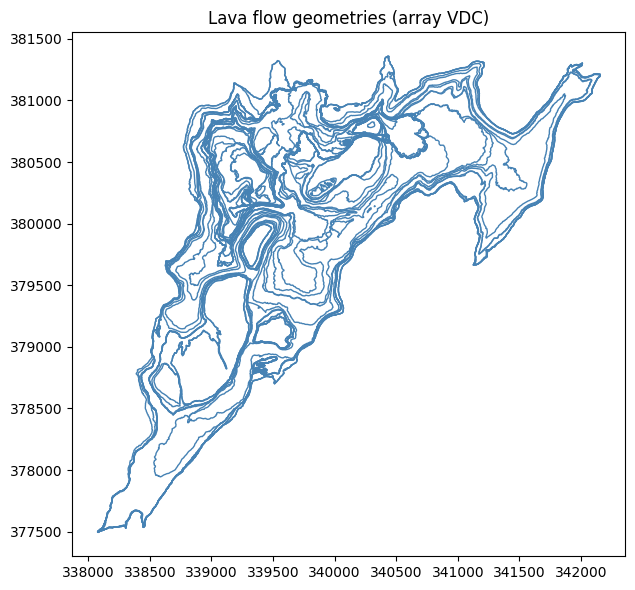

In [30]:
# Plot all changing geometries from the array
fig, ax = plt.subplots(figsize=(8, 6))
geoms_flat = cube_arr_lf.values.flatten()
for g in geoms_flat:
    if g is not None:
        gpd.GeoSeries([g], crs=3057).plot(ax=ax, facecolor="none", edgecolor="steelblue")
ax.set_title("Lava flow geometries (array VDC)")
plt.tight_layout()
plt.savefig('../data/output/Lava flow geometries (array VDC).png', bbox_inches='tight', pad_inches=0)
plt.show()
plt.close()

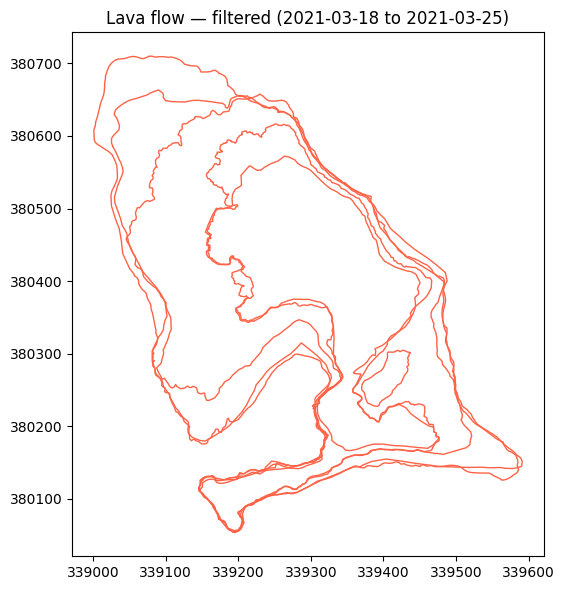

In [31]:
# Filtered subset
fig, ax = plt.subplots(figsize=(8, 6))
for g in cube_arr_lf_filtered.values.flatten():
    if g is not None:
        gpd.GeoSeries([g], crs=3057).plot(ax=ax, facecolor="none", edgecolor="tomato")
ax.set_title("Lava flow — filtered (2021-03-18 to 2021-03-25)")
plt.tight_layout()
plt.savefig('../data/output/Lava flow — filtered (2021-03-18 to 2021-03-25).png', bbox_inches='tight', pad_inches=0)
plt.show()
plt.close()

#### Maps with tabular VCDs

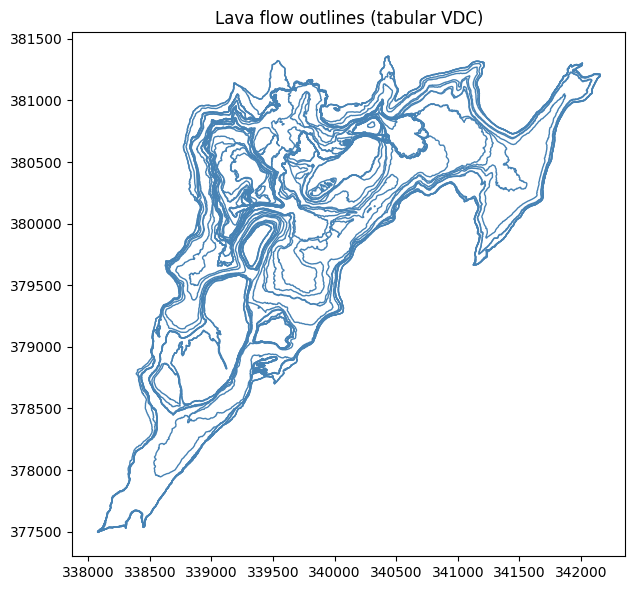

In [32]:
# Simple map (≈ ggplot + geom_sf)
fig, ax = plt.subplots(figsize=(8, 6))
(
    temporal_lf
    .sort_values("datetime", ascending=False)
    .set_geometry("geometry")
    .plot(ax=ax, facecolor="none", edgecolor="steelblue")
)
ax.set_title("Lava flow outlines (tabular VDC)")
plt.tight_layout()
plt.savefig('../data/output/Lava flow outlines (tabular VDC).png', bbox_inches='tight', pad_inches=0)
plt.show()
plt.close()

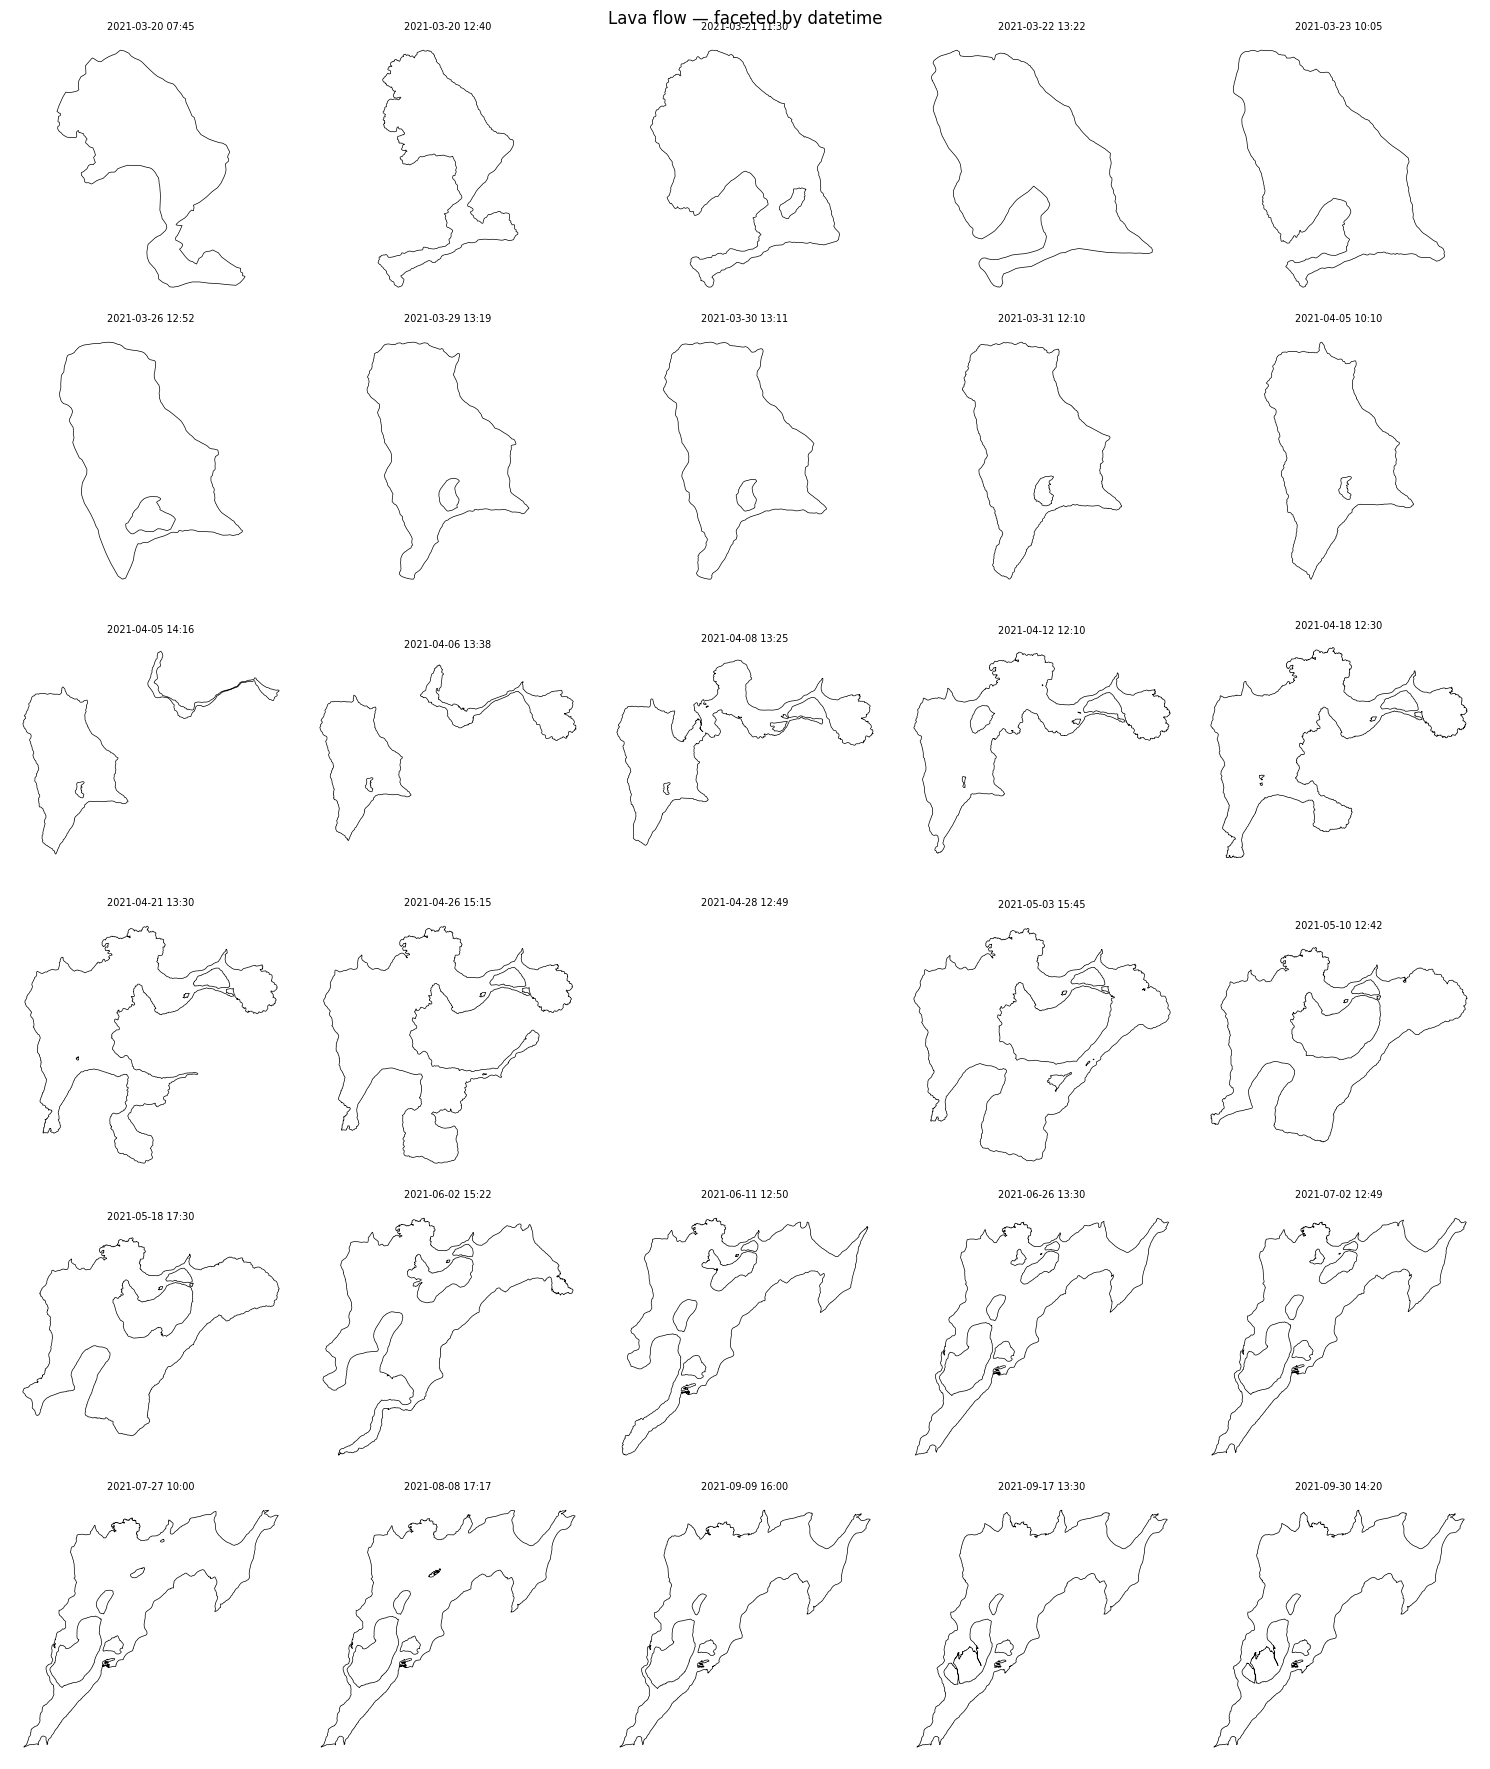

In [33]:
# Faceted map  (≈ facet_wrap(~datetime))
dates_plot = sorted(temporal_lf["datetime"].unique())
n = len(dates_plot)
cols = 5
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 3))
axes = axes.flatten()
for i, dt in enumerate(dates_plot):
    sub = temporal_lf[temporal_lf["datetime"] == dt]
    sub.plot(ax=axes[i], facecolor="none", edgecolor="black", linewidth=0.5)
    axes[i].set_title(str(dt)[:16], fontsize=7)
    axes[i].axis("off")
for j in range(i + 1, len(axes)):
    axes[j].axis("off")
plt.suptitle("Lava flow — faceted by datetime", fontsize=12)
plt.tight_layout()
plt.savefig('../data/output/Lava flow — faceted by datetime.png', bbox_inches='tight', pad_inches=0)
plt.show()
plt.close()

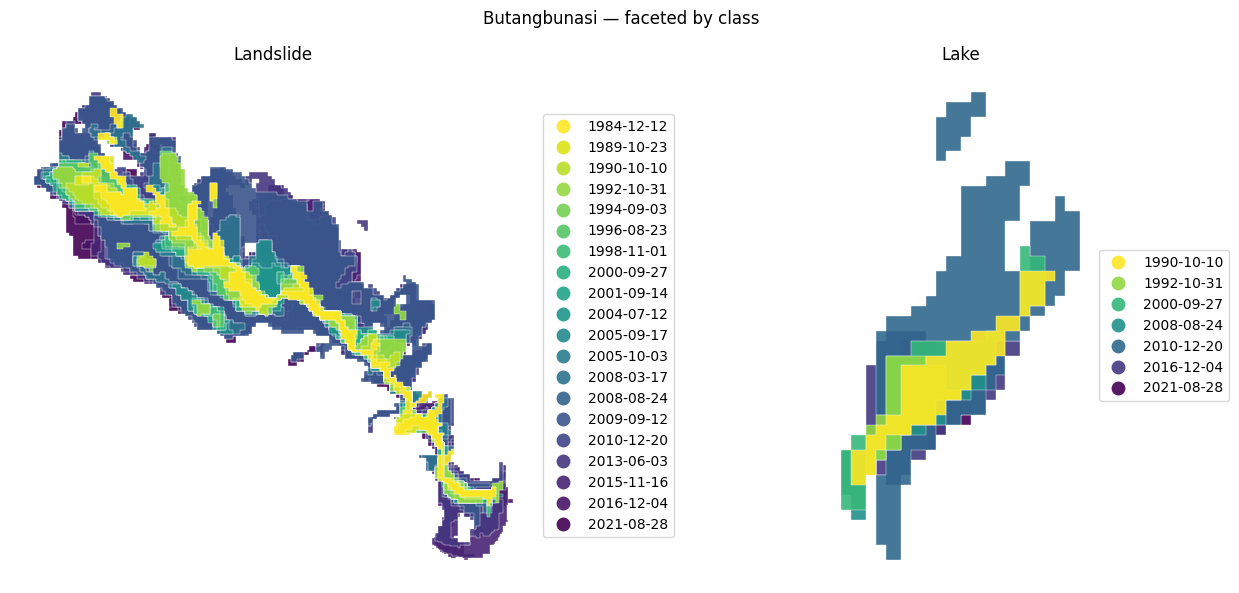

In [34]:
# Landslide tmap-style (≈ tm_polygons faceted by class)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, cls in zip(axes, ["landslide", "lake"]):
    sub = temporal_ldsl[temporal_ldsl["class"] == cls].dropna(subset=["geometry"])
    sub = sub.sort_values("date", ascending=False)
    sub.plot(ax=ax, column="date", cmap="viridis_r", alpha=0.9,
             edgecolor="white", linewidth=0.3, legend=True, legend_kwds={"loc": "center left", "bbox_to_anchor": (1, 0.5)},)
    ax.set_title(cls.capitalize())
    ax.axis("off")
plt.suptitle("Butangbunasi — faceted by class")
plt.tight_layout()
plt.savefig('../data/output/Butangbunasi — faceted by class.png', bbox_inches='tight', pad_inches=0)
plt.show()
plt.close()

#### Multi-dimensional plot

In the paper we included an example of a multi-dimensional visualisation of the VDC data. This was achieved by adding a distortion to the geometries to make them appear stacked over each other.

C:\Users\b1120440\AppData\Local\Temp\ipykernel_36128\2925584930.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("viridis")


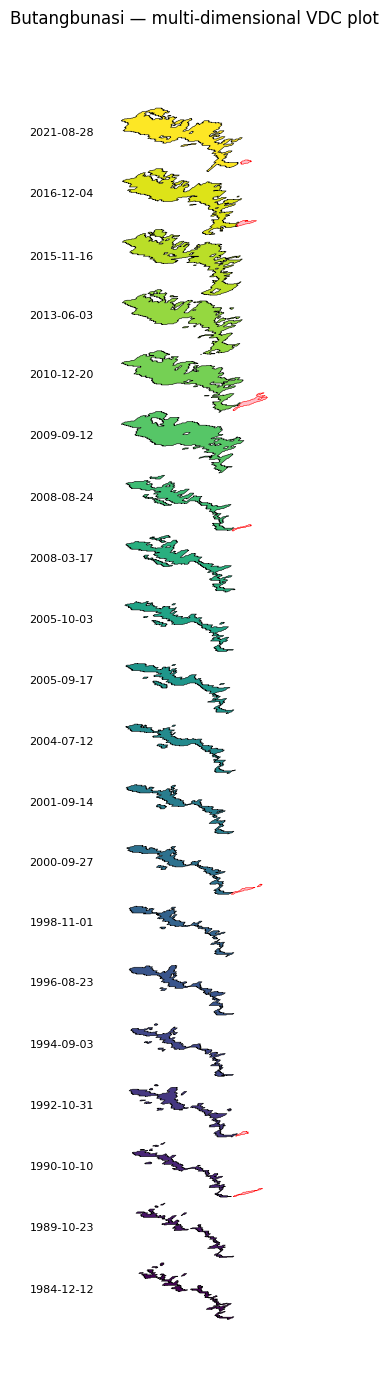

In [35]:
# Shear matrix coefficients  (≈ sm = matrix(c(2.5,1.2,0,1), 2,2) in R)
# shapely affine_transform([a,b,d,e,xoff,yoff]) → [ax+by+xoff, dx+ey+yoff]
a, b_, d, e = 2.5, 1.2, 0.0, 1.0

all_dates_ls = sorted(temporal_ldsl["date"].unique())
date_to_idx  = {dt: i + 1 for i, dt in enumerate(all_dates_ls)}

ldsl_shear = []
for _, row in temporal_ldsl.iterrows():
    if row["geometry"] is None:
        continue
    geom = row["geometry"]
    # Apply shear
    geom_s = affine_transform(geom, [a, b_, d, e, 0, 0])
    # Stack vertically
    shift_y = date_to_idx[row["date"]] * 4000
    geom_shifted = affine_transform(geom_s, [1, 0, 0, 1, 0, shift_y])
    ldsl_shear.append({
        "class": row["class"],
        "date": row["date"],
        "geometry": geom_shifted,
    })

ldsl_shear_gdf = gpd.GeoDataFrame(ldsl_shear, geometry="geometry")

fig, ax = plt.subplots(figsize=(8, 14))
cmap = cm.get_cmap("viridis")
date_nums = {dt: i / max(len(all_dates_ls) - 1, 1)
             for i, dt in enumerate(all_dates_ls)}

for _, row in ldsl_shear_gdf[ldsl_shear_gdf["class"] == "landslide"].iterrows():
    color = cmap(date_nums[row["date"]])
    gpd.GeoSeries([row["geometry"]]).plot(
        ax=ax, facecolor=color, edgecolor="black", linewidth=0.4
    )

for _, row in ldsl_shear_gdf[ldsl_shear_gdf["class"] == "lake"].iterrows():
    gpd.GeoSeries([row["geometry"]]).plot(
        ax=ax, facecolor="pink", edgecolor="red", linewidth=0.4
    )

# Date labels
for dt in all_dates_ls:
    sub = ldsl_shear_gdf[
        (ldsl_shear_gdf["class"] == "landslide") &
        (ldsl_shear_gdf["date"]  == dt)
    ]
    if sub.empty:
        continue
    y_label = sub["geometry"].centroid.y.iloc[0]
    ax.text(3_751_500, y_label, str(dt), fontsize=8, va="center")

ax.set_title("Butangbunasi — multi-dimensional VDC plot")
ax.axis("off")
plt.tight_layout()
plt.savefig('../data/output/Butangbunasi — multi-dimensional VDC plot.png', bbox_inches='tight', pad_inches=0)
plt.show()
plt.close()

#### Time series plot

As we are working with spatio-temporal data, to visualise the time component comes as natural. We can extract information both from the array and tabular format to do so.

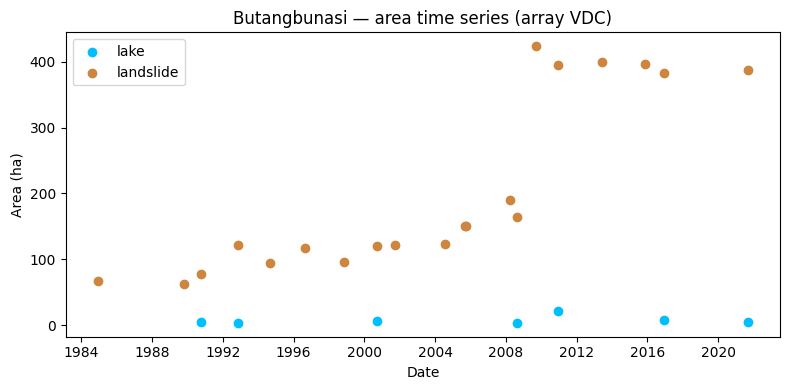

In [36]:
# Array VDC — scatter plot
fig, ax = plt.subplots(figsize=(8, 4))
colors = {"landslide": "peru", "lake": "deepskyblue"}
for i, cls in enumerate(classes_ls):
    areas = [area_arr[i, j] for j in range(n_date)]
    ax.scatter(dates_ls, areas, color=colors[cls], label=cls, zorder=3)
ax.set_xlabel("Date")
ax.set_ylabel("Area (ha)")
ax.set_title("Butangbunasi — area time series (array VDC)")
ax.legend()
plt.tight_layout()
plt.savefig('../data/output/Butangbunasi — area time series (array VDC).png', bbox_inches='tight', pad_inches=0)
plt.show()
plt.close()

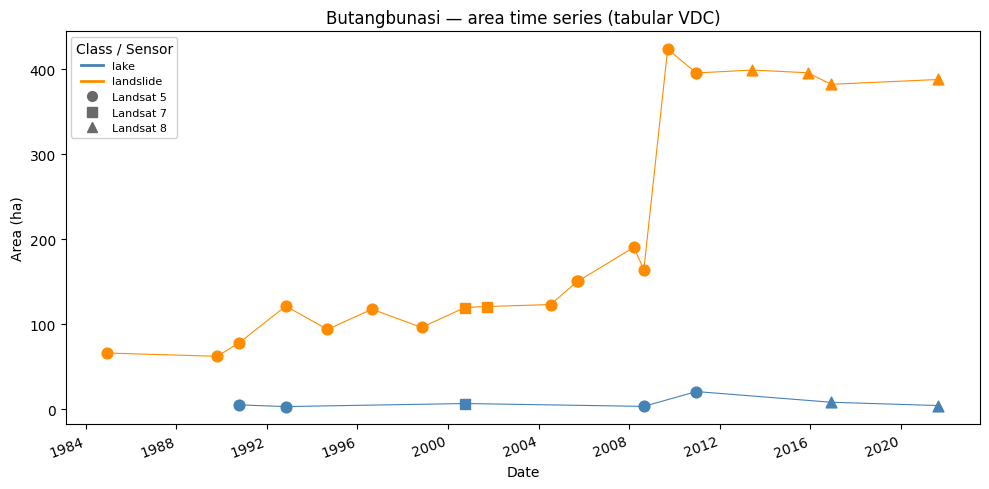

In [37]:
sub_all = temporal_ldsl.dropna(subset=["area_ha", "date"]).copy()
sub_all["date_dt"] = pd.to_datetime(sub_all["date"])

class_colors = {"landslide": "darkorange", "lake": "steelblue"}

sensor_vals    = sorted(sub_all["sensor"].dropna().unique())
marker_list    = ["o", "s", "^", "D", "v", "P", "X", "*"]
sensor_markers = {s: marker_list[i % len(marker_list)] for i, s in enumerate(sensor_vals)}

fig, ax = plt.subplots(figsize=(10, 5))

for cls in sorted(sub_all["class"].unique()):
    sub   = sub_all[sub_all["class"] == cls].sort_values("date_dt")
    color = class_colors[cls]                          # ← used here
    ax.plot(sub["date_dt"], sub["area_ha"],
            color=color, linewidth=0.8, zorder=2)      # ← and here
    for sensor, grp in sub.groupby("sensor"):
        ax.scatter(
            grp["date_dt"], grp["area_ha"],
            marker=sensor_markers[sensor],
            color=color, s=60, zorder=3                # ← and here
        )

# Two-section legend: class colours + sensor shapes
class_handles = [
    Line2D([0], [0], color=class_colors[c], linewidth=2, label=c)
    for c in sorted(class_colors)
]
sensor_handles = [
    Line2D([0], [0], marker=sensor_markers[s], color="dimgrey",
           markerfacecolor="dimgrey", markersize=7, linestyle="None", label=s)
    for s in sensor_vals
]
ax.legend(handles=class_handles + sensor_handles,
          title="Class / Sensor", loc="upper left", fontsize=8, framealpha=0.9)

ax.set_xlabel("Date")
ax.set_ylabel("Area (ha)")
ax.set_title("Butangbunasi — area time series (tabular VDC)")
fig.autofmt_xdate(rotation=20)
plt.tight_layout()
plt.savefig('../data/output/Butangbunasi — area time series (tabular VDC).png', bbox_inches='tight', pad_inches=0)
plt.show()
plt.close()

#### Glyph-style map

Glyph map is cubble's geom_glyph function used for mini time-series axes at each feature's centroid. The idea is to summarise time series data in a map format. The concept works as an innovative way to communicate spatio-temporal variation. 
But since we are not using R, this is an alternative.

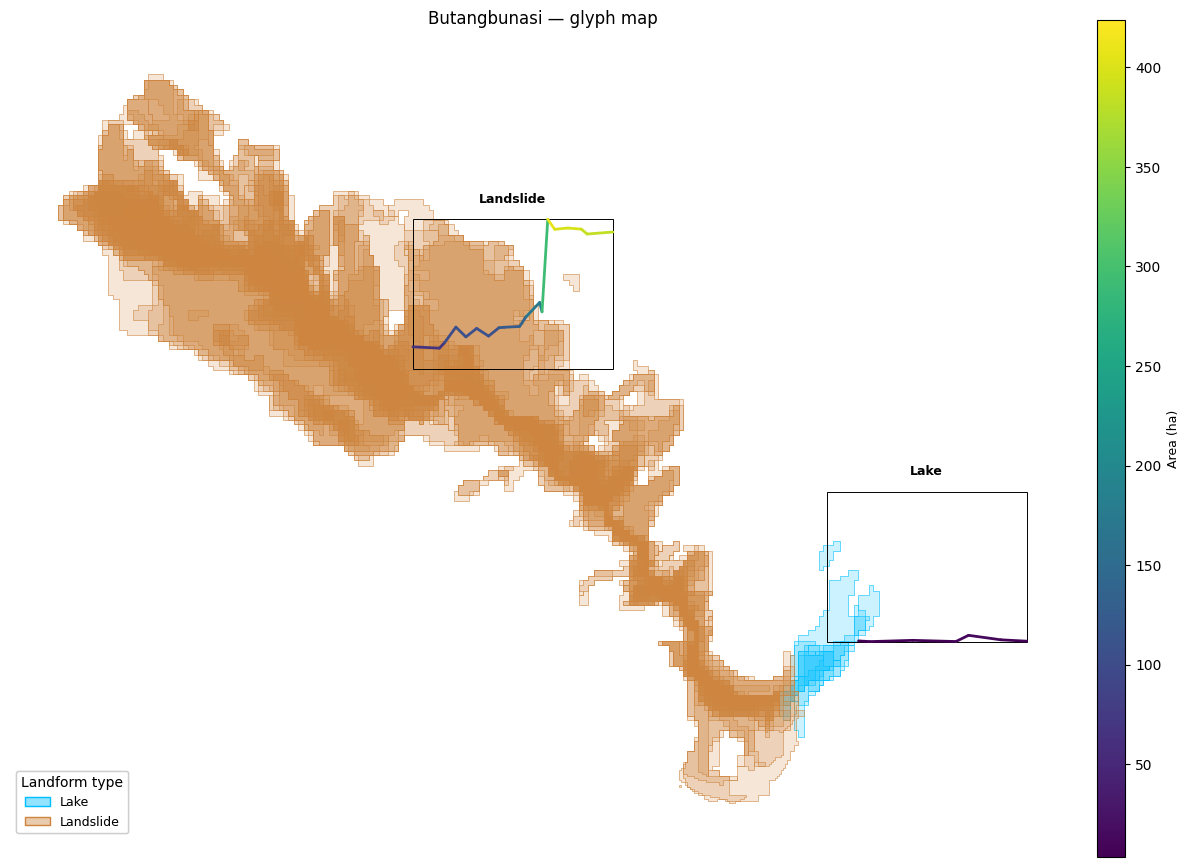

In [38]:
class_colors_glyph = {"landslide": "peru", "lake": "deepskyblue"}

fig, ax = plt.subplots(figsize=(12, 10))

# --- Background outlines coloured by class -----------------------------------
bg = temporal_ldsl.dropna(subset=["geometry"]).copy()
for cls, grp in bg.groupby("class"):
    gpd.GeoDataFrame(grp, geometry="geometry", crs=temporal_ldsl.crs).plot(
        ax=ax,
        facecolor=mcolors.to_rgba(class_colors_glyph[cls], alpha=0.2),
        edgecolor=class_colors_glyph[cls],
        linewidth=0.4,
    )

# --- Glyphs: mini time-series line at each class centroid --------------------
# Collect global area range for a shared colour normalisation across glyphs
all_areas = temporal_ldsl["area_ha"].dropna().astype(float)
norm_area  = mcolors.Normalize(vmin=all_areas.min(), vmax=all_areas.max())
cmap_area  = plt.cm.viridis

# Glyph box size in CRS units — adjust if the map extent changes
w, h = 1200, 900

# Shared axis ranges across all classes so glyphs are comparable
_all = temporal_ldsl.dropna(subset=["area_ha", "date"]).copy()
global_date_min = pd.to_datetime(_all["date"]).astype(np.int64).min()
global_date_max = pd.to_datetime(_all["date"]).astype(np.int64).max()
global_area_min = _all["area_ha"].astype(float).min()
global_area_max = _all["area_ha"].astype(float).max()

for cls in classes_ls:
    cx, cy = sum_geoms[cls].x, sum_geoms[cls].y
    sub = (
        temporal_ldsl[temporal_ldsl["class"] == cls]
        .dropna(subset=["area_ha"])
        .sort_values("date")
        .copy()
    )
    if sub.empty:
        continue

    dates_n = pd.to_datetime(sub["date"]).astype(np.int64).to_numpy()
    areas_n = sub["area_ha"].astype(float).to_numpy()

    # Normalise using shared global range so both glyphs are on the same scale
    dx = (dates_n - global_date_min) / (global_date_max - global_date_min + 1e-9) * w
    dy = (areas_n - global_area_min) / (global_area_max - global_area_min + 1e-9) * h

    # Colour each segment by the area value at that point
    for i in range(len(dx) - 1):
        seg_area = (areas_n[i] + areas_n[i + 1]) / 2
        seg_color = cmap_area(norm_area(seg_area))
        ax.plot(
            [cx + dx[i], cx + dx[i + 1]],
            [cy + dy[i], cy + dy[i + 1]],
            color=seg_color, linewidth=2, solid_capstyle="round"
        )

    # Glyph bounding box
    ax.add_patch(plt.Rectangle(
        (cx, cy), w, h,
        fill=False, edgecolor="black", linewidth=0.7
    ))
    # Class label above the box
    ax.text(cx + w / 2, cy + h + 80, cls.capitalize(),
            ha="center", va="bottom", fontsize=9, fontweight="bold")

# --- Legend 1: class fill patches --------------------------------------------
class_handles = [
    Patch(facecolor=mcolors.to_rgba(class_colors_glyph[c], 0.4),
          edgecolor=class_colors_glyph[c], label=c.capitalize())
    for c in sorted(class_colors_glyph)
]
leg1 = ax.legend(handles=class_handles, title="Landform type",
                 loc="lower left", fontsize=9, framealpha=0.9)
ax.add_artist(leg1)

# --- Legend 2: area colorbar -------------------------------------------------
sm = ScalarMappable(cmap=cmap_area, norm=norm_area)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, fraction=0.025, pad=0.02, aspect=30)
cbar.set_label("Area (ha)", fontsize=9)

ax.set_title("Butangbunasi — glyph map",
             fontsize=12, pad=10)
ax.axis("off")
plt.tight_layout()
plt.savefig('../data/output/Butangbunasi — glyph map.png', bbox_inches='tight', pad_inches=0)
plt.show()
plt.close()

## References



Hölbling, Daniel, Lorena Abad, Zahra Dabiri, Prasicek, and Anne-Laure Argentin. 2024. “Butangbunasi Landslide and Landslide-Dammed Lake Outlines Based on Landsat Time Series with Respect to Typhoons.” Zenodo. https://doi.org/10.5281/zenodo.10635102.

Pedersen, Gro B. M., Joaquin M. C. Belart, Birgir Vilhelm Óskarsson, Magnús Tumi Gudmundsson, Nils Gies, Thórdís Högnadóttir, Ásta Rut Hjartardóttir, et al. 2023. “Digital Elevation Models, Orthoimages and Lava Outlines of the 2021 Fagradalsfjall Eruption: Results from Near Real-Time Photogrammetric Monitoring.” Zenodo. https://doi.org/10.5281/zenodo.7866738 .


## Session Info

Equivalent to R's `sessionInfo()` — prints key library versions.

In [39]:
print(f"Python: {sys.version}")
print()

pkgs = [
    "geopandas", "xarray", "xvec", "pandas", "numpy",
    "matplotlib", "plotnine", "requests", "pint",
    "shapely", "pyarrow", "pint_pandas", "requests"
]
for pkg in pkgs:
    try:
        mod = importlib.import_module(pkg)
        version = getattr(mod, "__version__", "unknown")
        print(f"  {pkg}: {version}")
    except ImportError:
        print(f"  {pkg}: NOT INSTALLED")

Python: 3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]

  geopandas: 1.1.3
  xarray: 2026.2.0
  xvec: 0.5.2
  pandas: 3.0.1
  numpy: 2.4.3
  matplotlib: 3.10.8
  plotnine: 0.15.3
  requests: 2.32.5
  pint: 0.25.3
  shapely: 2.1.2
  pyarrow: 23.0.1
  pint_pandas: 0.8.0
  requests: 2.32.5
